# Asset-Allocation Backtester — Demo Walkthrough

This notebook demonstrates the engine end-to-end on the diversified 8-ETF universe:

1. Load monthly total returns (cached parquet).
2. Backtest a single strategy and read its tearsheet + headline metrics.
3. Compare every strategy on a benchmark-relative basis.
4. Decompose contribution to **return** and to **risk** by asset.

Every metric is computed from scratch in `backtester.metrics` — nothing here is a black box.

In [1]:
import logging
logging.basicConfig(level=logging.WARNING)
import pandas as pd
pd.options.display.float_format = lambda v: f'{v:,.4f}'

from backtester.config import load_config
from backtester.data import load_price_data
from backtester.report import run_config, format_summary_frame
from backtester.analysis import comparison_table, attribution_tables
from backtester import plotting
import matplotlib.pyplot as plt
%matplotlib inline

## 1. Data
Adjusted-close (total-return) history is pulled once via yfinance and cached to `data/`. The universe is aligned to its longest common monthly history — here the binding constraint is **BIL** (T-bills), which lists in 2007.

In [2]:
pd_data = load_price_data(['VTI','VEA','VWO','AGG','TIP','GLD','VNQ','BIL'])
returns = pd_data.monthly_returns
print(f'{returns.shape[1]} assets, {returns.index.min().date()} -> {returns.index.max().date()}, {len(returns)} months')
returns.tail(3)

8 assets, 2007-08-31 -> 2026-06-30, 227 months


,AGG,BIL,GLD,TIP,VEA,VNQ,VTI,VWO
Date,,,,,,,,
2026-04-30,0.0017,0.0029,-0.0154,0.0109,0.0737,0.0860,0.1040,0.0903
2026-05-31,0.0029,0.0032,-0.0154,0.0019,0.0432,-0.0065,0.0518,0.0161
2026-06-30,-0.0008,-0.0002,-0.1168,-0.0160,-0.0020,0.0165,-0.0039,-0.0020


## 2. Backtest a single strategy
We run the classic **60/40** (VTI/AGG, quarterly rebalanced) and print its headline metrics versus the default 60/40 benchmark.

In [3]:
cfg = load_config('configs/60_40.yaml')
bundle = run_config(cfg, price_data=pd_data)
summary = pd.DataFrame({cfg.name: bundle.summary})
format_summary_frame(summary.T).T

,60/40
CAGR,8.73%
Ann. Return (arith),8.93%
Ann. Volatility,10.26%
Sharpe,0.75
Sortino,1.16
Max Drawdown,26.42%
Calmar,0.33
Active Return,-0.05%
Tracking Error,0.28%
Information Ratio,-0.17


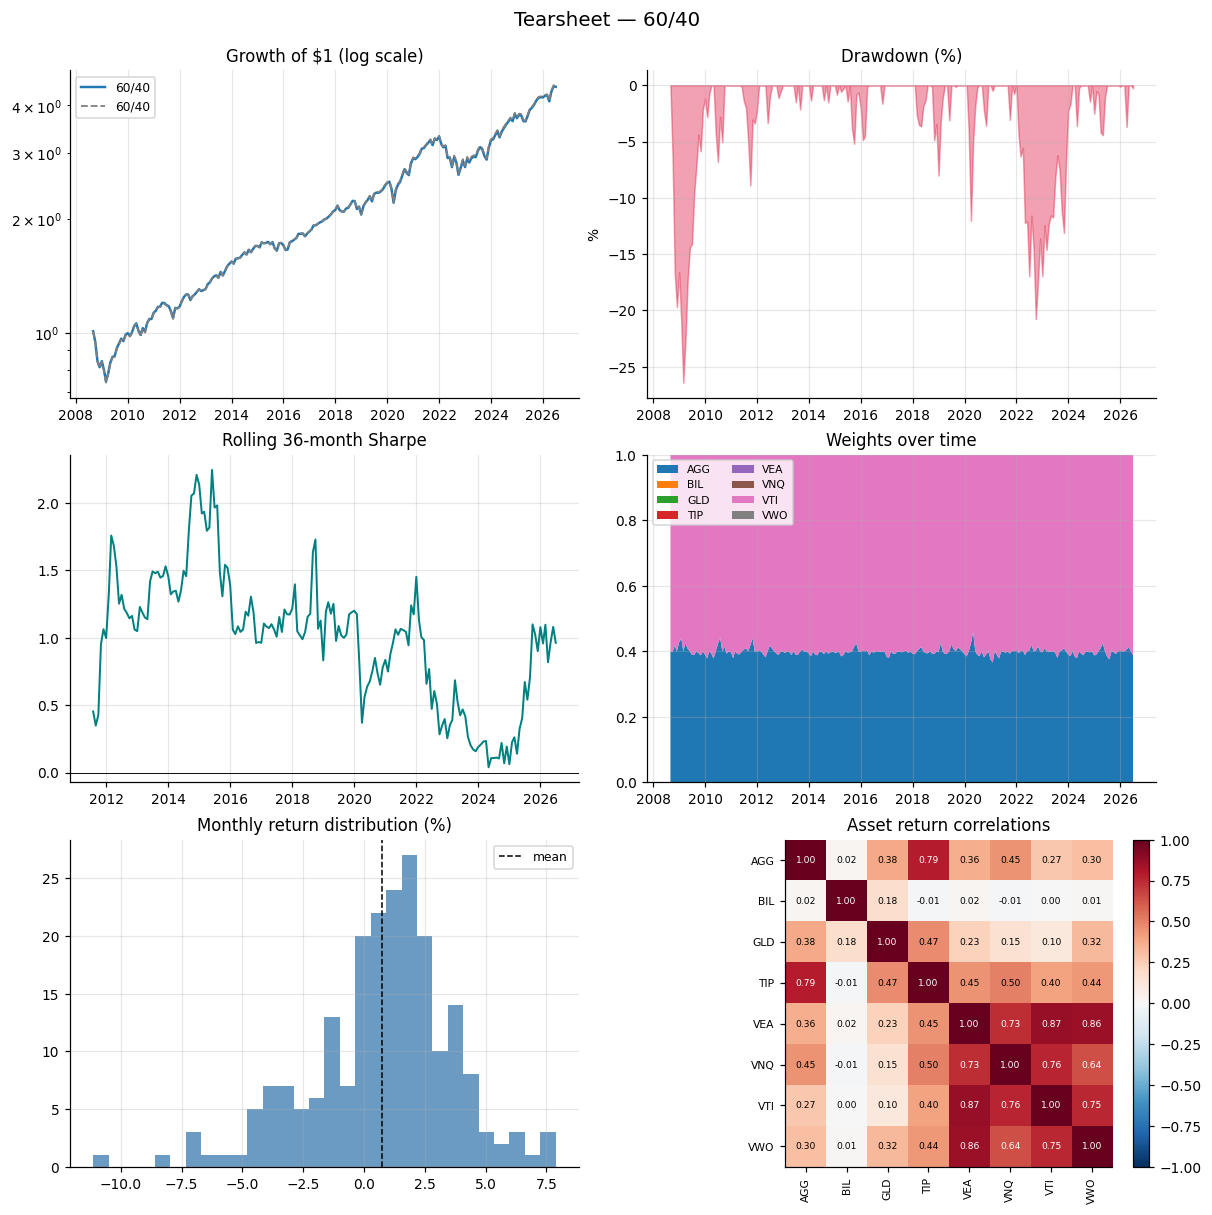

In [4]:
fig = plotting.tearsheet(bundle.result, bundle.benchmark, bundle.rf, returns)
fig.set_size_inches(11, 11)
plt.show()

## 3. Compare all strategies
All configs are aligned to their common window and scored on the same benchmark. Rows are strategies; the benchmark is appended for reference.

In [5]:
import glob
bundles = [run_config(load_config(p), price_data=pd_data) for p in sorted(glob.glob('configs/*.yaml'))]
table = comparison_table([b.result for b in bundles], bundles[0].benchmark, bundles[0].rf,
                         benchmark_name=bundles[0].result.config.benchmark.name)
format_summary_frame(table)

,CAGR,Ann. Return (arith),Ann. Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Active Return,Tracking Error,Information Ratio,Beta,Alpha,Up Capture,Down Capture,Annual Turnover,Annual Cost Drag
40/60,6.83%,6.92%,7.63%,0.75,1.16,18.68%,0.37,-2.06%,3.23%,-0.64,0.72,0.10%,0.74,0.70,5.72%,0.01%
60/40,8.77%,8.97%,10.37%,0.75,1.15,26.89%,0.33,0.00%,0.00%,—,1.00,0.00%,1.00,1.00,—,0.00%
Buy & Hold 60/40,9.96%,10.20%,11.57%,0.78,1.21,24.54%,0.41,1.23%,2.12%,0.58,1.10,0.44%,1.12,1.11,0.00%,0.00%
Equal Weight,6.23%,6.57%,10.02%,0.53,0.80,25.47%,0.24,-2.41%,4.69%,-0.51,0.86,-1.35%,0.79,0.86,7.95%,0.02%
Glide Path 30->65,6.54%,7.10%,12.08%,0.49,0.71,33.12%,0.20,-1.87%,5.74%,-0.33,1.02,-2.07%,0.91,1.05,4.67%,0.01%
Inverse Vol,5.36%,5.55%,7.90%,0.55,0.82,19.02%,0.28,-3.42%,5.54%,-0.62,0.65,-0.69%,0.60,0.60,33.12%,0.07%
Min Variance,3.13%,3.20%,4.74%,0.42,0.66,16.45%,0.19,-5.77%,8.64%,-0.67,0.26,-0.01%,0.27,0.19,33.44%,0.07%
Risk Parity (ERC),5.69%,5.84%,7.69%,0.60,0.92,17.28%,0.33,-3.13%,5.86%,-0.53,0.62,-0.15%,0.59,0.54,20.12%,0.04%
Target Vol 10%,5.09%,5.48%,9.85%,0.43,0.60,25.01%,0.20,-3.50%,5.12%,-0.68,0.83,-2.17%,0.74,0.87,21.32%,0.04%


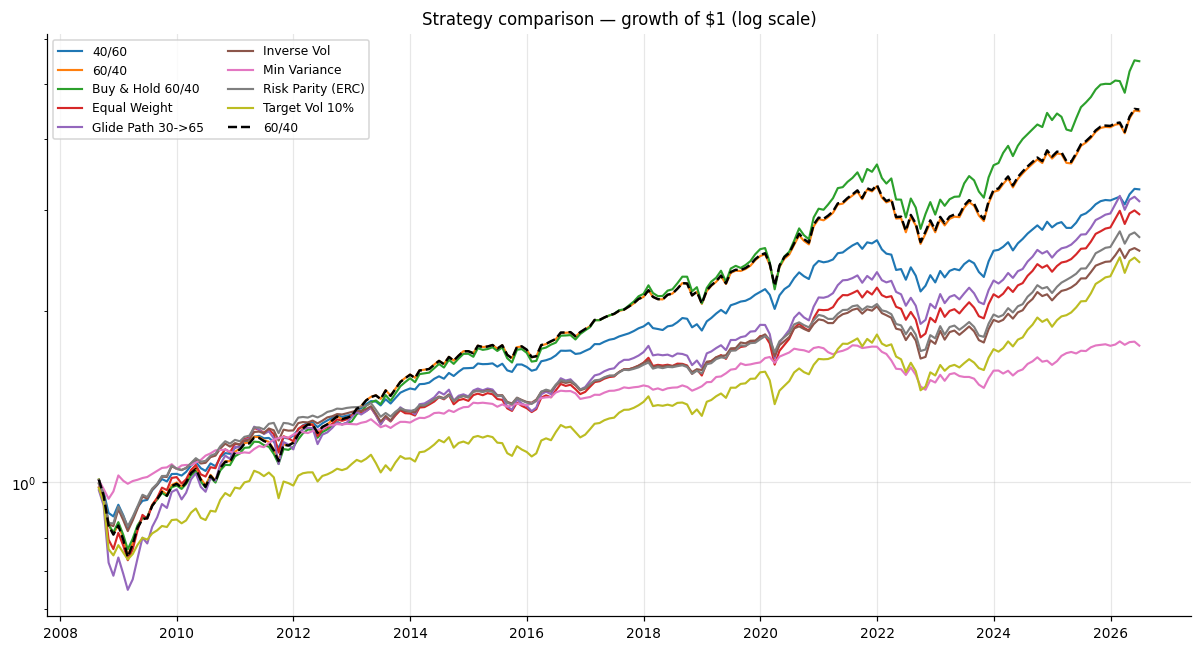

In [6]:
fig = plotting.comparison_equity_chart([b.result for b in bundles], bundles[0].benchmark)
plt.show()

## 4. Attribution
For the **Risk Parity (ERC)** strategy, where did return and risk come from? Note how ERC equalizes each asset's *risk* contribution even though dollar weights differ.

In [7]:
erc = next(b for b in bundles if b.result.config.strategy.type == 'risk_parity')
ctr, ctrisk = attribution_tables(erc.result, returns)
print('Contribution to RETURN:'); display(ctr.round(4))
print('Contribution to RISK:'); display(ctrisk.round(4))

Contribution to RETURN:


,contribution,pct_of_total
GLD,0.2629,0.2495
VTI,0.2016,0.1913
AGG,0.1922,0.1824
TIP,0.1149,0.1091
VEA,0.1048,0.0995
VWO,0.0972,0.0922
VNQ,0.0801,0.0760
BIL,0.0000,0.0000


Contribution to RISK:


,avg_weight,marginal_risk_contribution,risk_contribution,pct_of_risk
AGG,0.3680,0.0329,0.0121,0.1574
VTI,0.0901,0.1237,0.0111,0.1450
VNQ,0.0628,0.1762,0.0111,0.1440
VEA,0.0736,0.1500,0.0110,0.1437
TIP,0.2340,0.0457,0.0107,0.1390
VWO,0.0655,0.1623,0.0106,0.1381
GLD,0.1059,0.0965,0.0102,0.1329
BIL,0.0000,0.0003,0.0000,0.0000


---
**Takeaway.** Over 2007–present, rebalanced 60/40 and buy-&-hold 60/40 lead on absolute and risk-adjusted return in this equity-friendly sample, while min-variance / risk-parity deliver the lowest drawdowns and betas — exactly the risk/return trade-off you'd expect. See the README for the full methodology and every formula.